In [1]:
# === Notebook common preamble (load the llm_math package) ===
import sys
from pathlib import Path

# Candidate paths for the llm_math package
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# Add parent directories as candidates (when running from the notebooks folder)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# Try importing llm_math
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[Warning] load the llm_math package text: {e}")
    print("  Clone the GitHub repository and run colab_setup.sh.")
# === end preamble ===


# Ch 06. text MLPtext — text Training text

> **Learning Goals**
> - text text text(XOR Problem)text text text
> - text text text text text
> - MLPtext NumPytext text text

## 6.1 text text text

text(1957, Rosenblatt)text text text text:

$$y = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

- $\mathbf{x} \in \mathbb{R}^d$: text
- $\mathbf{w} \in \mathbb{R}^d$: text
- $b \in \mathbb{R}$: text
- $\sigma$: text Function (step, sigmoid, etc.)

text: text text text textValue(0)text text 1, text 0.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from llm_math.data import make_xor_data, make_spiral_data

# text text
class Perceptron:
    def __init__(self, n_features, lr=0.1, n_epochs=100):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
        self.n_epochs = n_epochs

    def fit(self, X, y):
        for epoch in range(self.n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                pred = self.predict_one(xi)
                update = self.lr * (yi - pred)
                self.w += update * xi
                self.b += update
                if update != 0:
                    errors += 1
            if errors == 0:
                break

    def predict_one(self, x):
        return 1 if (np.dot(self.w, x) + self.b) >= 0 else 0

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

# AND, OR Training (text text text)
def make_and():
    X = np.array([[0,0], [0,1], [1,0], [1,1]])
    y = np.array([0, 0, 0, 1])
    return X, y

def make_or():
    X = np.array([[0,0], [0,1], [1,0], [1,1]])
    y = np.array([0, 1, 1, 1])
    return X, y

for name, (X, y) in [('AND', make_and()), ('OR', make_or())]:
    p = Perceptron(n_features=2, lr=0.1, n_epochs=100)
    p.fit(X, y)
    preds = p.predict(X)
    acc = np.mean(preds == y)
    print(f"{name}: w={p.w}, b={p.b:.2f}, acc={acc*100:.0f}%")


AND: w=[0.2 0.1], b=-0.20, acc=100%
OR: w=[0.1 0.1], b=-0.10, acc=100%


## 6.2 XOR Problem — text text text

XORtext text text text. text text text(1969, Minsky & Papert)text text text text text text.

| $x_1$ | $x_2$ | XOR |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

text text 1text 0text text text text. **text**text text.


XOR (text): w=[-0.1  0. ], b=0.00
Prediction: [1 1 0 0], Label: [0 1 1 0]
Accuracy: 50% (50%textPlane text text)


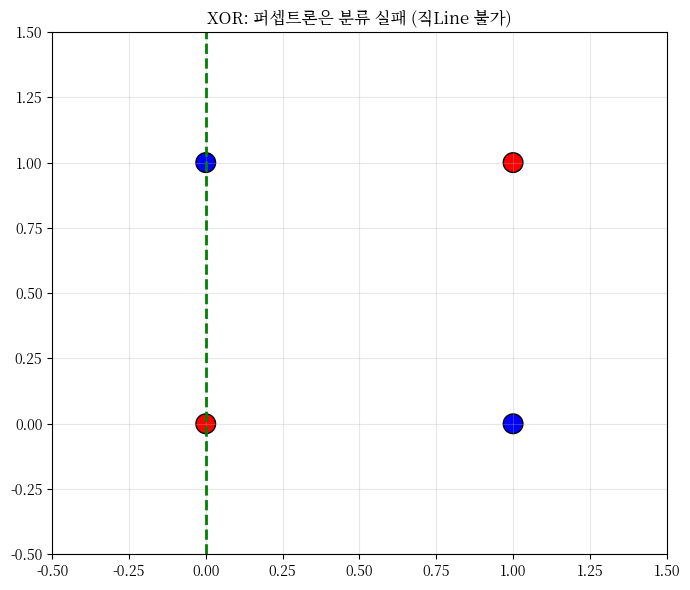

In [3]:
# XOR Training textdegrees (text text)
X_xor, y_xor = make_xor_data()
y_xor_flat = y_xor.flatten()

p = Perceptron(n_features=2, lr=0.1, n_epochs=1000)
p.fit(X_xor, y_xor_flat)
preds = p.predict(X_xor)
acc = np.mean(preds == y_xor_flat)
print(f"XOR (text): w={p.w}, b={p.b:.2f}")
print(f"Prediction: {preds}, Label: {y_xor_flat.astype(int)}")
print(f"Accuracy: {acc*100:.0f}% (50%textPlane text text)")

# Visualization: text text
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['red' if yi == 0 else 'blue' for yi in y_xor_flat]
ax.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolors='black')

# text Decision Boundary: w0*x + w1*y + b = 0
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
Z = p.w[0] * xx + p.w[1] * yy + p.b
ax.contour(xx, yy, Z, levels=[0], colors='green', linestyles='--', linewidths=2)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title('XOR: text text text (textLine text)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch06_xor_perceptron.png', dpi=100, bbox_inches='tight')
plt.show()


## 6.3 text text (MLP)

text text XORtext text text text:

$$\mathbf{h} = \sigma(W_1 \mathbf{x} + \mathbf{b}_1), \quad \mathbf{o} = W_2 \mathbf{h} + \mathbf{b}_2$$

- $W_1 \in \mathbb{R}^{h \times d}$: text → text
- $W_2 \in \mathbb{R}^{o \times h}$: text → Output
- $\sigma$: text text (sigmoid, ReLU, ...)

**text text text(UAT)**: text textdegrees text text Functiontext text textdegreestext text text text (text text text text).


XOR Training text text: [0 1 1 0]
Label: [0 1 1 0]
Accuracy: 100%


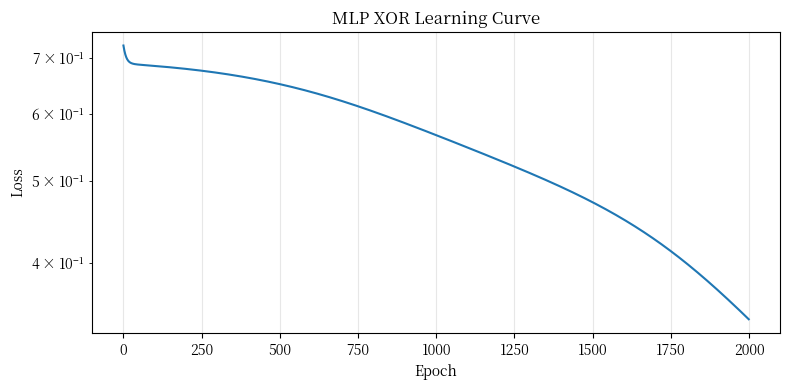

In [4]:
# MLPtext NumPytext text (XOR Training)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

class MLPNumPy:
    """text MLP: 2 -> 4 -> 1 (NumPy Implementation)."""
    def __init__(self, n_in=2, n_hidden=4, n_out=1, seed=0):
        rng = np.random.default_rng(seed)
        # He/Xavier text
        self.W1 = rng.standard_normal((n_in, n_hidden)) * np.sqrt(2.0 / n_in)
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.standard_normal((n_hidden, n_out)) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros(n_out)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1       # (N, h)
        self.h = sigmoid(self.z1)              # (N, h)
        self.z2 = self.h @ self.W2 + self.b2   # (N, 1)
        self.out = sigmoid(self.z2)            # (N, 1)
        return self.out

    def backward(self, X, y, lr=0.5):
        N = X.shape[0]
        # OutputLayer Gradient
        dz2 = (self.out - y) * sigmoid_deriv(self.z2)  # (N, 1)
        dW2 = self.h.T @ dz2 / N                        # (h, 1)
        db2 = dz2.mean(axis=0)                          # (1,)
        # textLayer Gradient
        dh = dz2 @ self.W2.T                            # (N, h)
        dz1 = dh * sigmoid_deriv(self.z1)               # (N, h)
        dW1 = X.T @ dz1 / N                             # (d, h)
        db1 = dz1.mean(axis=0)                          # (h,)
        # text
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def loss(self, y_pred, y_true):
        return np.mean(-(y_true * np.log(y_pred + 1e-12) + (1 - y_true) * np.log(1 - y_pred + 1e-12)))

# XOR Training
X_xor, y_xor = make_xor_data()  # (4, 2), (4, 1)
mlp = MLPNumPy(n_in=2, n_hidden=4, n_out=1, seed=42)

losses = []
for epoch in range(2000):
    pred = mlp.forward(X_xor)
    l = mlp.loss(pred, y_xor)
    losses.append(l)
    mlp.backward(X_xor, y_xor, lr=0.5)

# Result
preds = (mlp.forward(X_xor) > 0.5).astype(int)
print(f"XOR Training text text: {preds.flatten()}")
print(f"Label: {y_xor.flatten().astype(int)}")
print(f"Accuracy: {np.mean(preds.flatten() == y_xor.flatten().astype(int)) * 100:.0f}%")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP XOR Learning Curve')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig('../figures/ch06_mlp_xor_loss.png', dpi=100, bbox_inches='tight')
plt.show()


## 6.4 text text Visualization

MLPtext XORtext text text 2D Spacetext text.


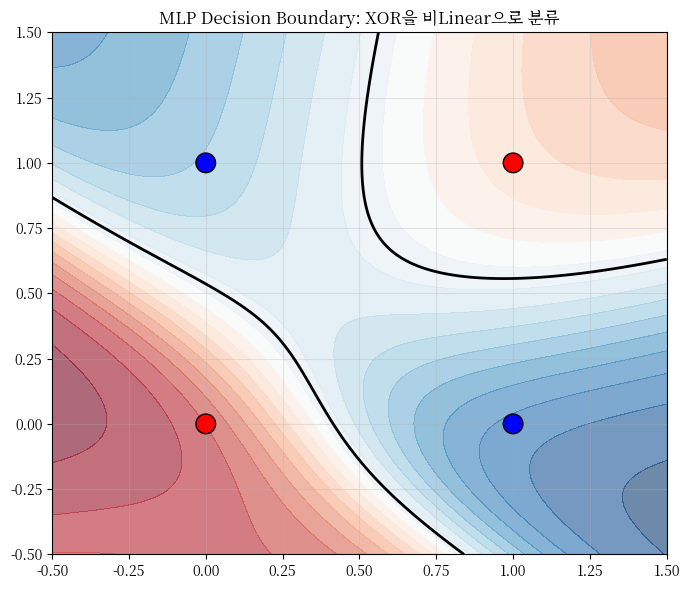

MLPtext textLinear Decision Boundarytext text XORtext text!


In [5]:
# MLP text text Visualization
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.forward(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
colors = ['red' if yi == 0 else 'blue' for yi in y_xor.flatten()]
ax.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolors='black', zorder=5)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title('MLP Decision Boundary: XORtext textLineartext text')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch06_mlp_xor_boundary.png', dpi=100, bbox_inches='tight')
plt.show()
print("MLPtext textLinear Decision Boundarytext text XORtext text!")


## 6.5 MNIST text — MLP text text

text text Datatext text. MNIST text (28x28 = 784 text)text MLPtext text.


In [6]:
# MNIST text (MLP, NumPy)
from llm_math.data import load_mnist_small

X_train, y_train, X_test, y_test = load_mnist_small(n_train=5000, n_test=1000)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Label Distribution: {np.bincount(y_train)}")

# text Encoding
def one_hot(y, n_classes=10):
    onehot = np.zeros((y.shape[0], n_classes))
    onehot[np.arange(y.shape[0]), y] = 1.0
    return onehot

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

# MLP: 784 -> 64 -> 10
class MLPClassifier:
    def __init__(self, n_in, n_hidden, n_out, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((n_in, n_hidden)) * np.sqrt(2.0 / n_in)
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.standard_normal((n_hidden, n_out)) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros(n_out)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.h = np.maximum(0, self.z1)  # ReLU
        self.z2 = self.h @ self.W2 + self.b2
        # softmax
        z2 = self.z2 - self.z2.max(axis=1, keepdims=True)
        e = np.exp(z2)
        self.out = e / e.sum(axis=1, keepdims=True)
        return self.out

    def backward(self, X, y, lr=0.1):
        N = X.shape[0]
        dz2 = (self.out - y) / N  # softmax + CE text
        dW2 = self.h.T @ dz2
        db2 = dz2.sum(axis=0)
        dh = dz2 @ self.W2.T
        dz1 = dh * (self.z1 > 0)  # ReLU text
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def loss(self, y_pred, y_true):
        return -np.mean(np.sum(y_true * np.log(y_pred + 1e-12), axis=1))

# Training
mlp = MLPClassifier(784, 64, 10, seed=42)
batch_size = 64
n_epochs = 20
losses = []
accs = []

for epoch in range(n_epochs):
    # text
    idx = np.random.default_rng(epoch).permutation(len(X_train))
    for i in range(0, len(X_train), batch_size):
        bi = idx[i:i+batch_size]
        Xb, yb = X_train[bi], y_train_oh[bi]
        mlp.forward(Xb)
        mlp.backward(Xb, yb, lr=0.1)
    # text
    pred = mlp.forward(X_train)
    l = mlp.loss(pred, y_train_oh)
    acc = np.mean(pred.argmax(axis=1) == y_train)
    losses.append(l); accs.append(acc)
    print(f"Epoch {epoch+1:2d}: loss={l:.4f}, train_acc={acc*100:.2f}%")

# Test Accuracy
test_pred = mlp.forward(X_test).argmax(axis=1)
test_acc = np.mean(test_pred == y_test)
print(f"\ntext textdegrees: {test_acc*100:.2f}%")


Train: (5000, 784), Test: (1000, 784)
Label Distribution: [493 563 499 510 487 451 491 521 488 497]
Epoch  1: loss=0.5732, train_acc=84.44%
Epoch  2: loss=0.3907, train_acc=89.38%


Epoch  3: loss=0.4205, train_acc=85.84%
Epoch  4: loss=0.8962, train_acc=73.48%
Epoch  5: loss=0.4625, train_acc=86.10%


Epoch  6: loss=0.2529, train_acc=92.98%
Epoch  7: loss=0.3199, train_acc=89.74%
Epoch  8: loss=0.4220, train_acc=86.84%


Epoch  9: loss=0.2059, train_acc=94.52%
Epoch 10: loss=0.1830, train_acc=95.36%


Epoch 11: loss=0.2403, train_acc=92.40%
Epoch 12: loss=0.1857, train_acc=94.94%


Epoch 13: loss=0.1461, train_acc=96.40%
Epoch 14: loss=0.1487, train_acc=96.28%


Epoch 15: loss=0.4793, train_acc=83.86%
Epoch 16: loss=0.1269, train_acc=97.08%


Epoch 17: loss=0.1221, train_acc=96.94%
Epoch 18: loss=0.1199, train_acc=97.16%


Epoch 19: loss=0.2437, train_acc=91.14%
Epoch 20: loss=0.1688, train_acc=94.76%

text textdegrees: 90.50%


/tmp/ipykernel_15950/3642664335.py:24: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


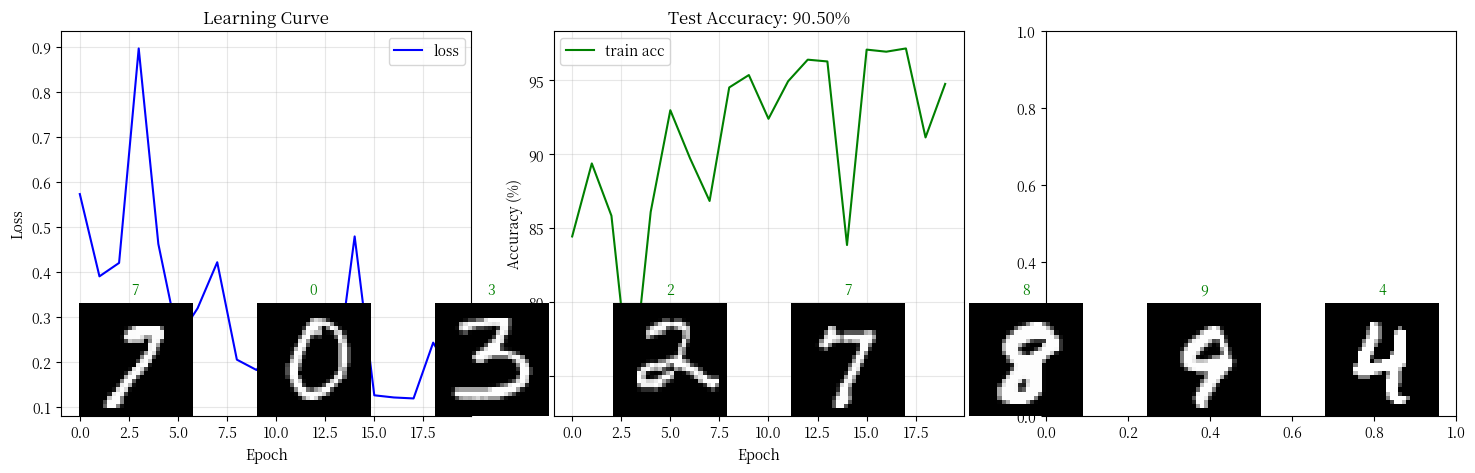

In [7]:
# Training text + text text Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training text
axes[0].plot(losses, 'b-', label='loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curve')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# textdegrees
axes[1].plot([a*100 for a in accs], 'g-', label='train acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title(f'Test Accuracy: {test_acc*100:.2f}%')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# text text
for i in range(8):
    ax = fig.add_subplot(3, 8, 17 + i)
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'{test_pred[i]}', color='green' if test_pred[i] == y_test[i] else 'red', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('../figures/ch06_mnist_mlp.png', dpi=100, bbox_inches='tight')
plt.show()


## 6.6 Key Takeaways

| text | text | text |
|---|---|---|
| text | $y = \sigma(\mathbf{w}^\top\mathbf{x} + b)$ | text text |
| MLP | $\mathbf{h}=\sigma(W_1\mathbf{x}), \mathbf{o}=W_2\mathbf{h}$ | text text |
| XOR Problem | — | text text text, text text |
| UAT | — | text 1text text textFunction text text |

## Exercises

1. text NAND Functiontext Trainingtext, text Outputtext.
2. text text text 2, 4, 8, 16text text XOR Training Speedtext Comparisontext.
3. MNIST MLPtext text 0text(text text), 1text, 2text text textdegreestext Comparisontext.
4. ReLU text sigmoidtext text text MNIST Trainingtext text text text.
5. text text text "text text text text"text text text.

> Solutions: `solutions/ch06_solutions.ipynb`
